In [1]:
# import numpy as np
from pyvolgrid import volume_from_spheres
# from JDFTxFreeNrg.testing import anl_spheres_volume
from JDFTxFreeNrg.testing import anl_3sphere_union_volume, anl_2sphere_union_volume, get_mesh_spheres_volume, get_monte_carlo_spheres_volume, get_pyvista_spheres_volume, anl_spheres_volume, get_pyvol_spheres_volume
import numpy as np
import timeit

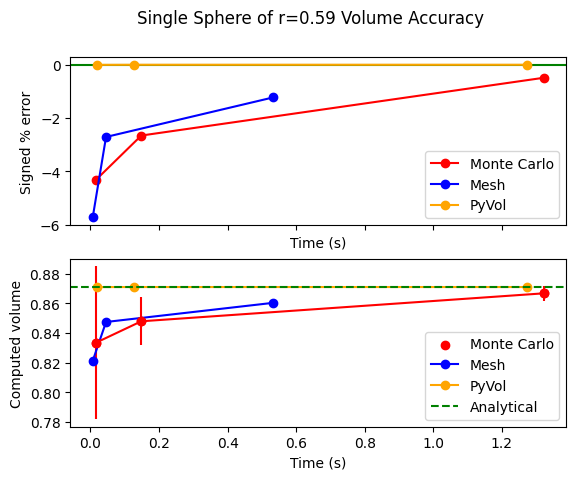

In [ ]:
from JDFTxFreeNrg.testing import anl_sphere_volume, get_mc_volume_samples, get_mesh_volume_samples, plot_volume_accuracy, get_pyvol_samples
import matplotlib.pyplot as plt

def test_single_sphere_volume(r: float | None = None, center: np.ndarray | None = None, nsampless: list[int] | None = None, mesh_sample_scale: float = 150., pyvista_sample_scale: float = 15., pyvol_sample_scale: float = 6000.):
    if r is None:
        r = np.random.random() + 0.5
    v_anl = anl_sphere_volume(r)
    rs = [r]
    if center is None:
        center = np.random.rand(3) * 10.0
    centers = [center]
    if nsampless is None:
        nsampless = [1e3, 1e4, 1e5]
    v_pvs, t_pvs = get_pyvol_samples(rs, centers, ncubess=np.array(nsampless)*pyvol_sample_scale)
    v_meshs, t_meshs = get_mesh_volume_samples(rs, centers, np.array(nsampless)*mesh_sample_scale)
    v_mcs, t_mcs, dev_mcs = get_mc_volume_samples(rs, centers, nsampless)
    # v_pvs, t_pvs = get_pyvista_volume_samples(rs, centers, np.sqrt(np.array(nsampless))*pyvista_sample_scale)
    
    fig, ax = plot_volume_accuracy(
        v_anl,
        [
            "Monte Carlo", "Mesh", "PyVol"
        ],
        {
            "Monte Carlo": v_mcs,
            "Mesh": v_meshs,
            "PyVol": v_pvs
        },
        {
            "Monte Carlo": t_mcs,
            "Mesh": t_meshs,
            "PyVol": t_pvs
        },
        {"Monte Carlo": dev_mcs},
        )
    fig.suptitle('Single Sphere of r={:.2f} Volume Accuracy'.format(r))
    plt.show()

test_single_sphere_volume(pyvol_sample_scale=7000.)

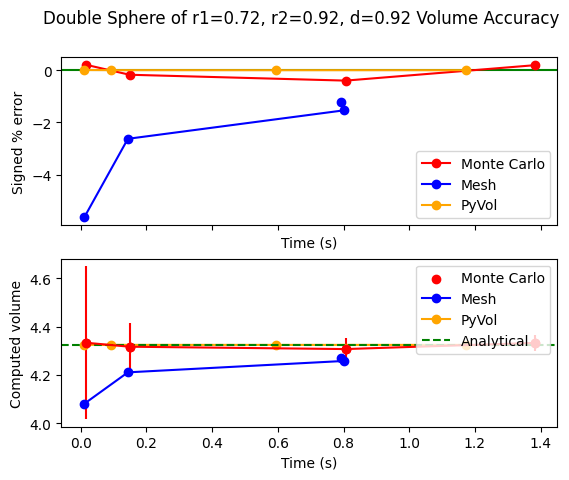

In [9]:
def test_double_sphere_volume(rs: list[float] | None = None, centers: list[np.ndarray] | None = None, nsampless: list[int] | None = None, mesh_sample_scale: float = 150., pyvista_sample_scale: float = 0.5, pyvol_sample_scale: float = 7000.):
    if rs is None:
        rs = [np.random.random() + 0.5, np.random.random() + 0.5]
    if centers is None:
        centers = [np.zeros(3), np.ones(3)*0.5+np.random.random(3)*0.1]
    v_anl = anl_2sphere_union_volume(rs[0], rs[1], np.linalg.norm(centers[0]-centers[1]))
    # nsampless = [1e3, 1e4, 1e5, 2e5, 3e5]
    # nsampless = [1e3, 1e4, 1e5]
    nsampless = [1e3, 1e4, 5e4, 1e5]
    v_meshs, t_meshs = get_mesh_volume_samples(rs, centers, np.array(nsampless)*mesh_sample_scale)
    v_mcs, t_mcs, dev_mcs = get_mc_volume_samples(rs, centers, nsampless)
    # v_pvs, t_pvs = get_pyvista_volume_samples(rs, centers, (np.array(nsampless)**(1/2))*pyvista_sample_scale)
    v_pvs, t_pvs = get_pyvol_samples(rs, centers, ncubess=np.array(nsampless)*pyvol_sample_scale)
    fig, ax = plot_volume_accuracy(
        v_anl,
        [
            "Monte Carlo", "Mesh", "PyVol"
        ],
        {
            "Monte Carlo": v_mcs,
            "Mesh": v_meshs,
            "PyVol": v_pvs
        },
        {
            "Monte Carlo": t_mcs,
            "Mesh": t_meshs,
            "PyVol": t_pvs
        },
        {"Monte Carlo": dev_mcs},
        )
    fig.suptitle('Double Sphere of r1={:.2f}, r2={:.2f}, d={:.2f} Volume Accuracy'.format(rs[0], rs[1], np.linalg.norm(centers[0]-centers[1])))
    plt.show()

test_double_sphere_volume()

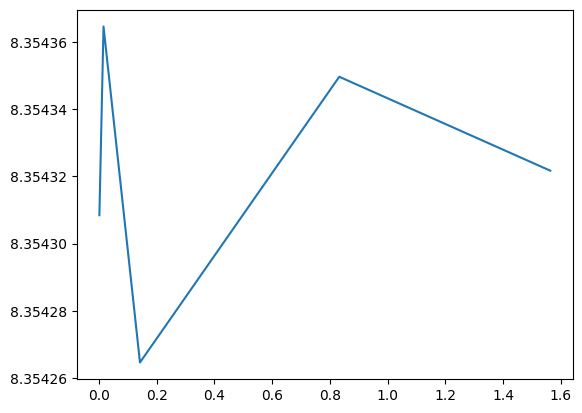

In [14]:
nsampless = [1e2, 1e3, 1e4, 5e4, 1e5]
pyvol_sample_scale = 7000.
rs = None
centers = None
if rs is None:
    rs = [np.random.random() + 0.5, np.random.random() + 0.5]
if centers is None:
    centers = [np.zeros(3), np.ones(3)*0.5+np.random.random(3)*0.1]
v_pvs, t_pvs = get_pyvol_samples(rs, centers, ncubess=np.array(nsampless)*pyvol_sample_scale)
plt.plot(t_pvs, v_pvs, label='PyVol')
plt.ticklabel_format(useOffset=False)